<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/Car_Resale_Price_Prediction_using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

In [2]:
#  importing the "drive" module from the "google.colab" library, facilitating access to Google Drive within a Colab notebook.
from google.colab import drive

In [3]:
# mounting the user's Google Drive to the "/content/drive" directory in a Google Colab notebook, enabling access to files and data stored on Google Drive within the Colab environment.
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# reading a CSV file named "data.csv" located in the "Data" folder on the your Google Drive and stores it as a DataFrame df
# write your data file path
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CarPred.csv')

In [5]:
df.head()

,make,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power,model,selling_price
0,hyundai,0,0,0,1,0,0,1,0,0,0,1,2009,42945,2492,287,verna,210447.937555
1,toyota,0,0,0,1,0,0,0,0,1,1,0,2003,176401,3240,88,corolla,272870.715932
2,ford,1,0,0,0,0,0,0,0,1,1,1,2018,46852,3250,169,aspire,251387.190744
3,honda,1,0,0,0,0,1,0,0,0,1,1,2014,162580,1317,99,jazz,139196.325731
4,hyundai,1,0,0,1,0,1,0,0,0,1,1,2004,11264,3268,196,i10,227022.794299


In [6]:
df.shape

(20000, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               20000 non-null  object 
 1   transmission_type  20000 non-null  int64  
 2   seats_cop          20000 non-null  int64  
 3   seats_family       20000 non-null  int64  
 4   seats_large        20000 non-null  int64  
 5   fuel_cng           20000 non-null  int64  
 6   fuel_diesel        20000 non-null  int64  
 7   fuel_electric      20000 non-null  int64  
 8   fuel_lpg           20000 non-null  int64  
 9   fuel_patrol        20000 non-null  int64  
 10  seller_dealer      20000 non-null  int64  
 11  seller_self        20000 non-null  int64  
 12  year               20000 non-null  int64  
 13  km_driven          20000 non-null  int64  
 14  engine             20000 non-null  int64  
 15  max_power          20000 non-null  int64  
 16  model              200

In [8]:
df.describe()

,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power,selling_price
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000
mean,0.499250,0.125150,0.250350,0.500400,0.030850,0.063550,0.123900,0.251050,0.499600,0.49835,0.494100,2010.513900,100041.14725,2999.009900,274.710600,266271.805771
std,0.500012,0.330897,0.433225,0.500012,0.172916,0.243956,0.329476,0.433628,0.500012,0.50001,0.499978,6.355032,57710.68638,1156.559718,129.841543,83920.890732
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2000.000000,1003.00000,1000.000000,50.000000,-12255.386175
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2005.000000,50202.75000,1995.000000,162.000000,206372.288854
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2011.000000,100031.50000,3017.000000,275.000000,266074.359288
75%,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,2016.000000,150444.00000,3994.000000,387.000000,326341.517397
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2021.000000,199990.00000,4999.000000,499.000000,561603.556063


Exploratory Data Analysis-Outliers

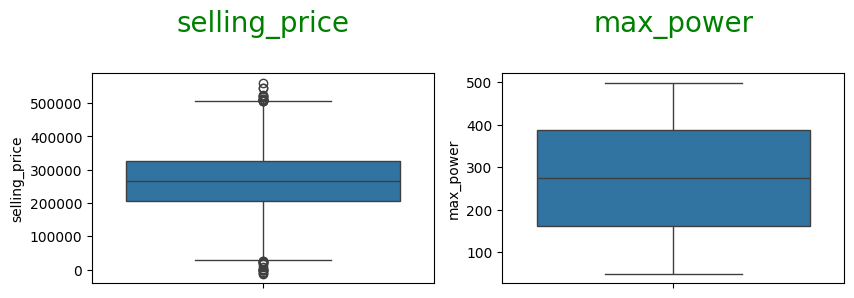

In [9]:
plt.figure(figsize=(15,6))

plt.subplot(2,3,1)
sns.boxplot(df["selling_price"])
plt.title("selling_price\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})

plt.subplot(2,3,2)
sns.boxplot(df["max_power"])
plt.title("max_power\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})



plt.show()

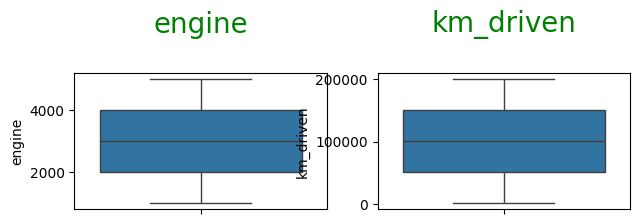

In [10]:
plt.figure(figsize=(15,6))

plt.subplot(3,4,1)
sns.boxplot(df["engine"])
plt.title("engine\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})

plt.subplot(3,4,2)
sns.boxplot(df["km_driven"])
plt.title("km_driven\n", fontdict={'fontsize': 20, 'fontweight' : 5, 'color' : 'Green'})

plt.show()


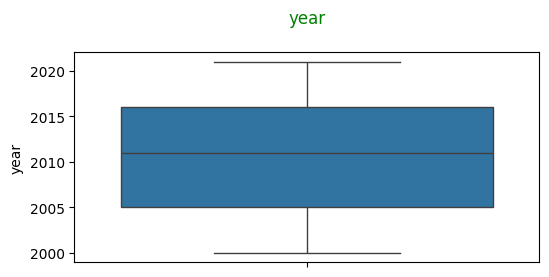

In [11]:
plt.figure(figsize=(6,6))

plt.subplot(2,1,1)
sns.boxplot(df["year"])
plt.title("year\n", fontdict={'fontsize': 12, 'fontweight' : 5, 'color' : 'Green'})




plt.show()

**From the above figure , we can see outliers present  for target variable selling_price. These can be real . so we are keeping those**

In [12]:
null_per_engine=(df["engine"].isnull().sum() / len(df)) * 100
null_per_engine

np.float64(0.0)

In [13]:
current_year = 2026

df["car_age"] = current_year - df["year"]
df.drop(columns=['year'], inplace=True)
df.head()

,make,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,km_driven,engine,max_power,model,selling_price,car_age
0,hyundai,0,0,0,1,0,0,1,0,0,0,1,42945,2492,287,verna,210447.937555,17
1,toyota,0,0,0,1,0,0,0,0,1,1,0,176401,3240,88,corolla,272870.715932,23
2,ford,1,0,0,0,0,0,0,0,1,1,1,46852,3250,169,aspire,251387.190744,8
3,honda,1,0,0,0,0,1,0,0,0,1,1,162580,1317,99,jazz,139196.325731,12
4,hyundai,1,0,0,1,0,1,0,0,0,1,1,11264,3268,196,i10,227022.794299,22


Univariate Analysis

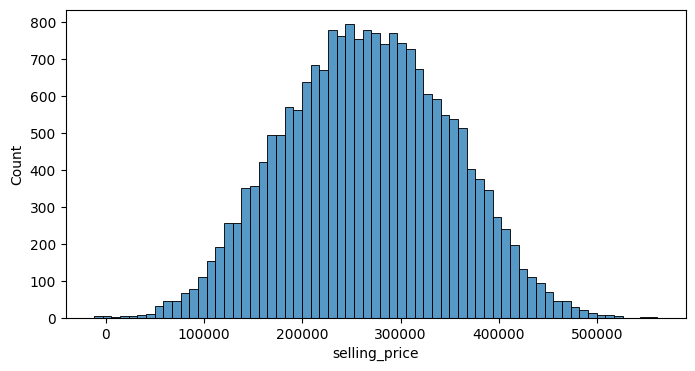

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df["selling_price"]);

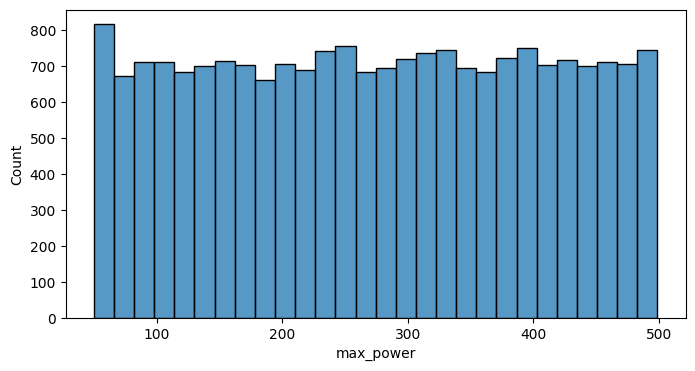

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(df["max_power"]);

<Axes: xlabel='car_age', ylabel='Count'>

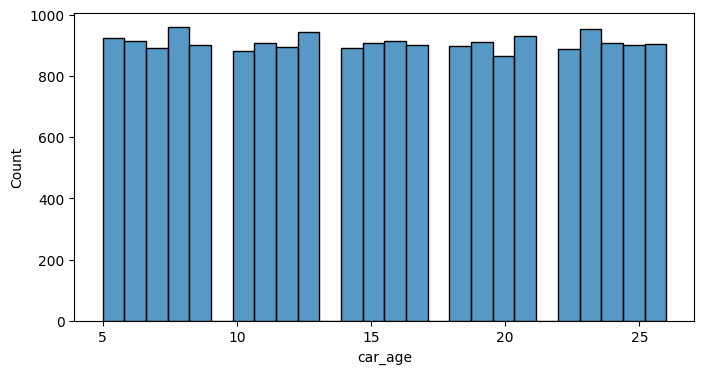

In [16]:
plt.figure(figsize=(8,4))
sns.histplot(df["car_age"])

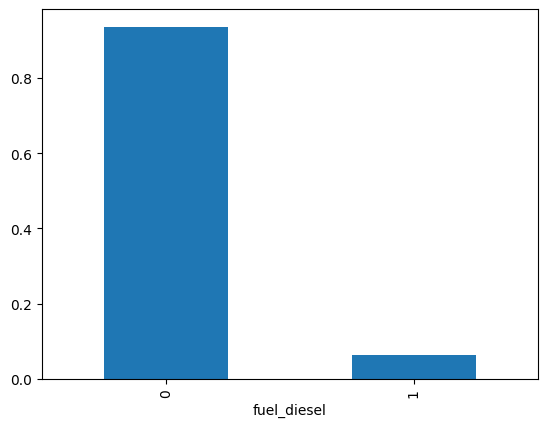

In [17]:

df["fuel_diesel"].value_counts(normalize=True).plot.bar()
plt.show()

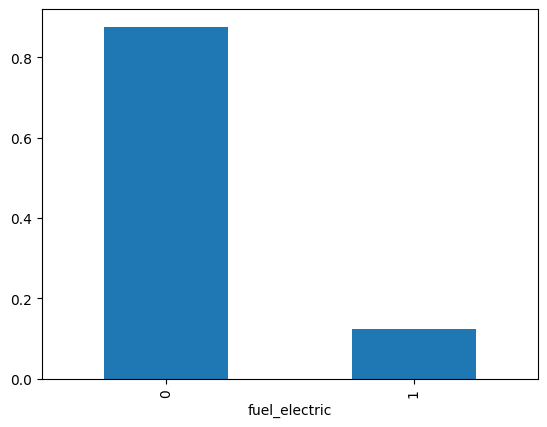

In [18]:
df["fuel_electric"].value_counts(normalize=True).plot.bar()
plt.show()

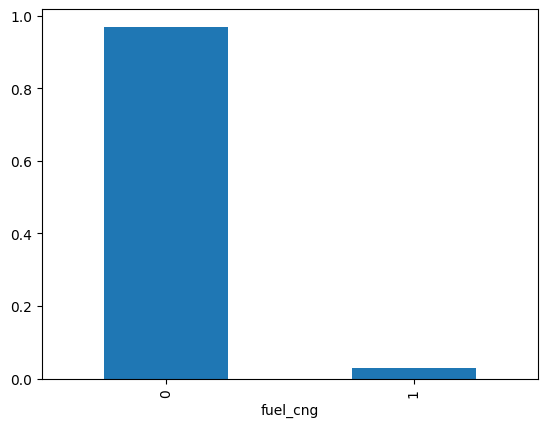

In [19]:
df["fuel_cng"].value_counts(normalize=True).plot.bar()
plt.show()

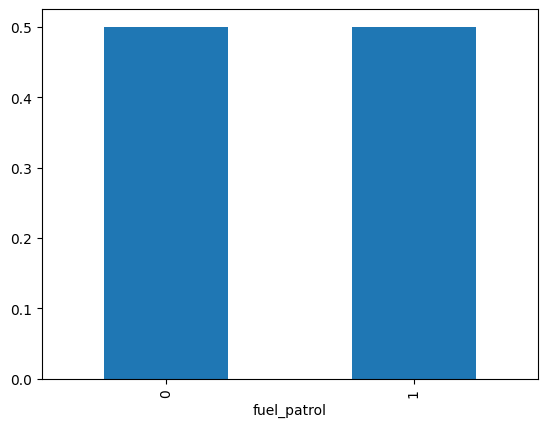

In [20]:
df["fuel_patrol"].value_counts(normalize=True).plot.bar()
plt.show()

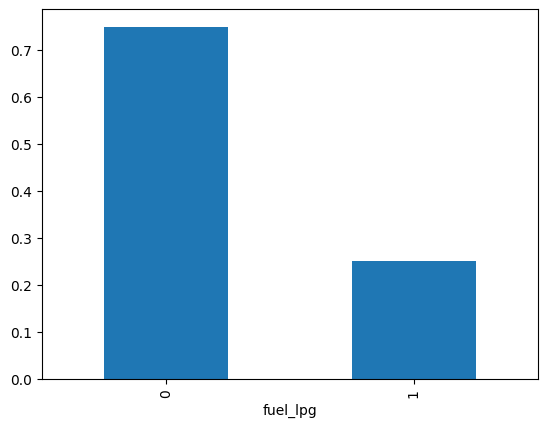

In [21]:
df["fuel_lpg"].value_counts(normalize=True).plot.bar()
plt.show()

<Axes: xlabel='km_driven', ylabel='Count'>

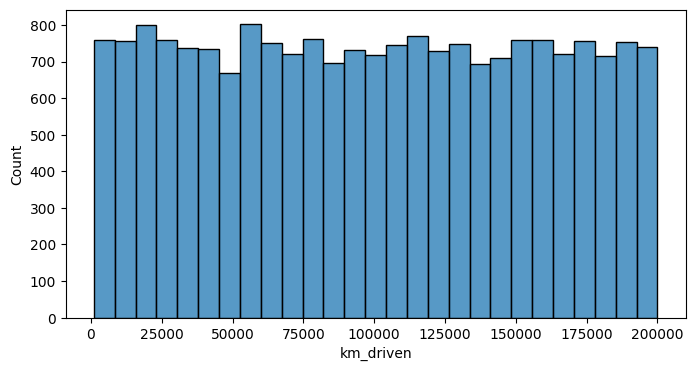

In [22]:

plt.figure(figsize=(8,4))
sns.histplot(df["km_driven"])

<Axes: xlabel='engine', ylabel='Count'>

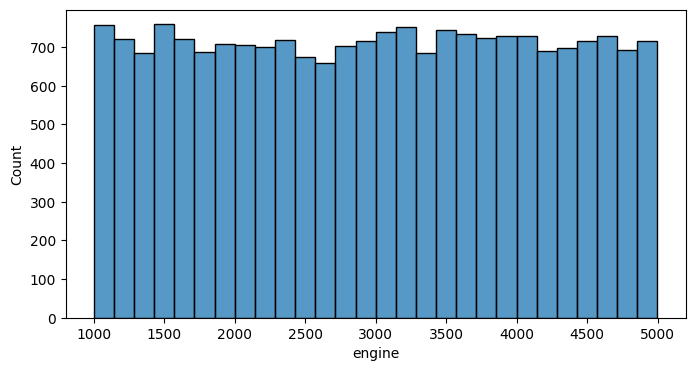

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(df["engine"])

Bivariate Analysis

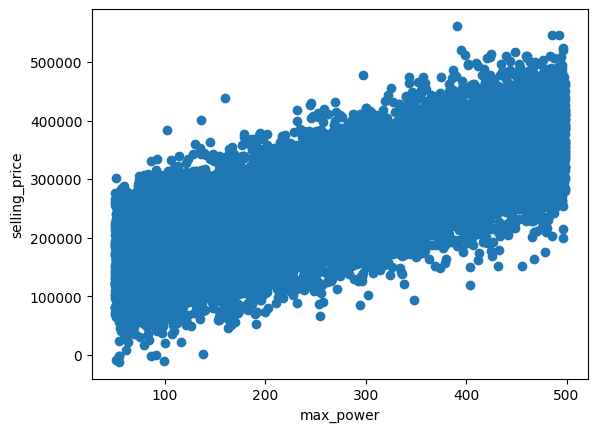

In [24]:
x = df["max_power"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("max_power")
plt.ylabel("selling_price")
plt.show()

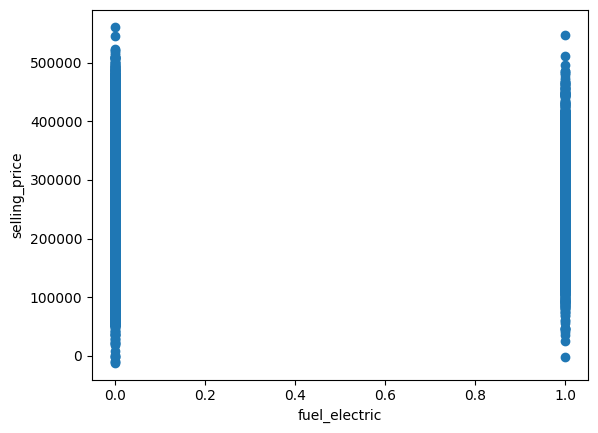

In [25]:
x = df["fuel_electric"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("fuel_electric")
plt.ylabel("selling_price")
plt.show()

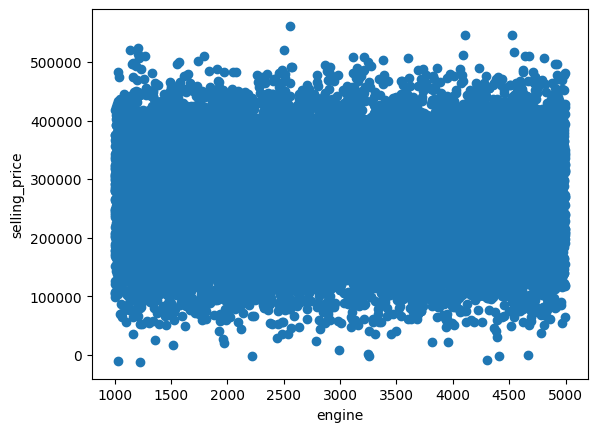

In [26]:
x = df["engine"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("engine")
plt.ylabel("selling_price")
plt.show()

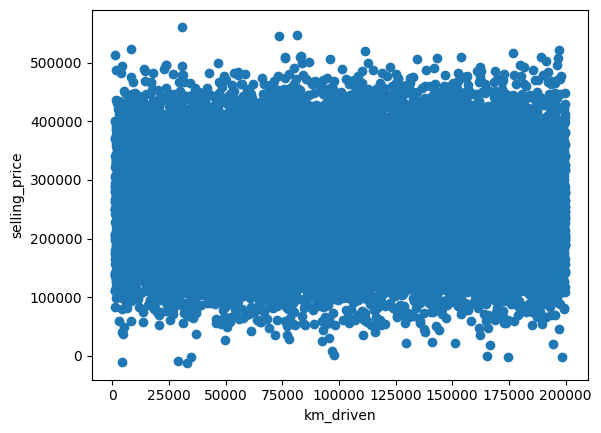

In [27]:
x = df["km_driven"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("km_driven")
plt.ylabel("selling_price")
plt.show()

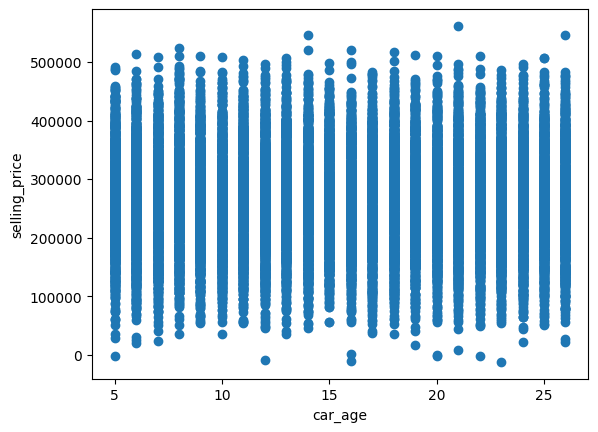

In [28]:
x = df["car_age"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("car_age")
plt.ylabel("selling_price")
plt.show()

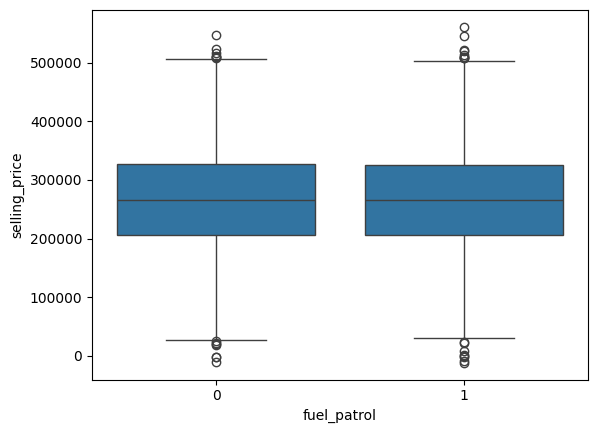

In [29]:
sns.boxplot(x = df["fuel_patrol"], y = df["selling_price"]);

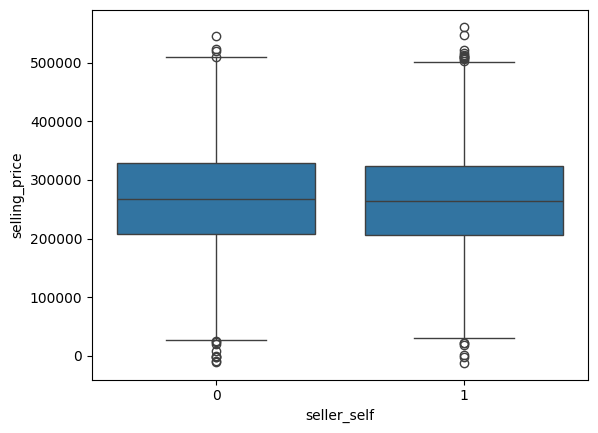

In [30]:
sns.boxplot(x = df["seller_self"], y = df["selling_price"]);

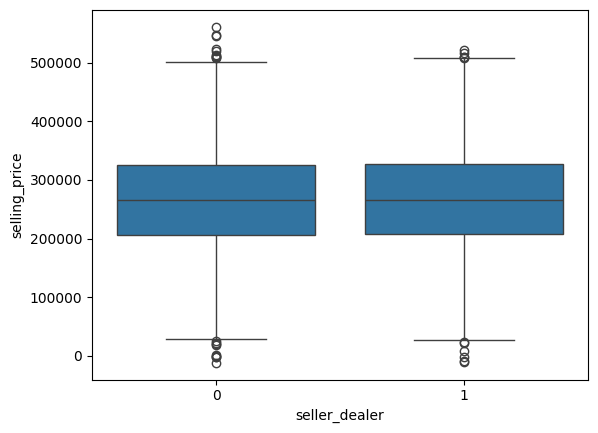

In [31]:
sns.boxplot(x = df["seller_dealer"], y = df["selling_price"]);

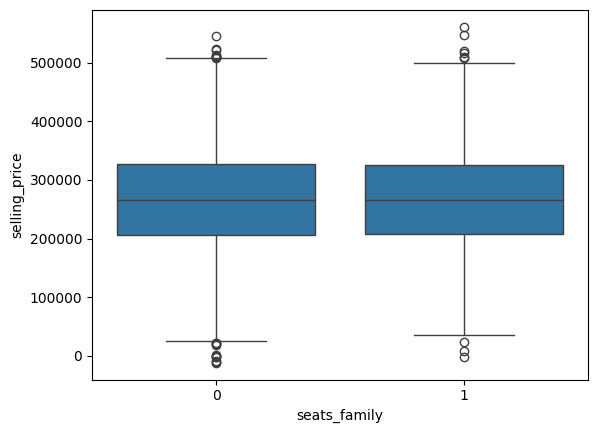

In [32]:
sns.boxplot(x = df["seats_family"], y = df["selling_price"]);

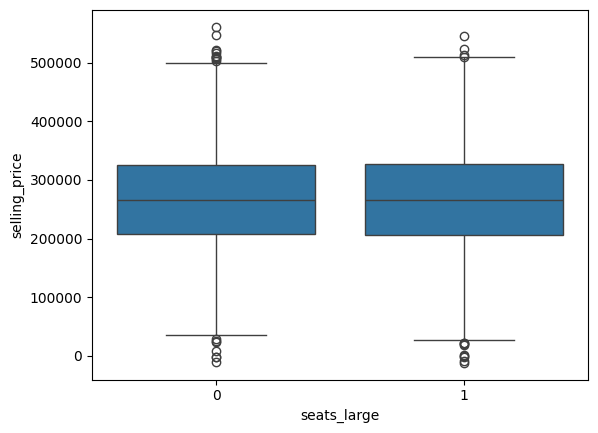

In [33]:
sns.boxplot(x = df["seats_large"], y = df["selling_price"]);

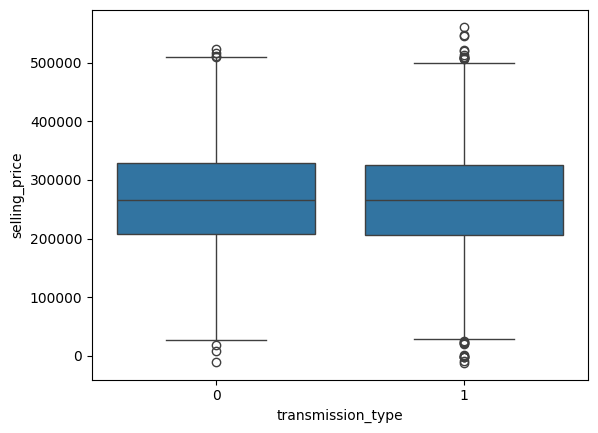

In [34]:

sns.boxplot(x = df["transmission_type"], y = df["selling_price"]);

**Multivariate Analysis**

In [35]:
df["max_power_grp"] = pd.cut(df["max_power"],bins=[0, 50, 200, 400,float('inf')], labels = ["<50", "50-200", "201-400", ">400"])

In [36]:
pd1 = pd.pivot_table(data = df, index = "make", columns = "max_power_grp", values = "selling_price")
pd1

max_power_grp,<50,50-200,201-400,>400
make,,,,
ford,160349.781219,192587.459119,281100.460864,350453.831343
honda,149019.544767,192766.276355,278429.246408,352829.180132
hyundai,162724.293376,192660.992599,277157.737029,354204.117057
maruti,171490.006046,191741.454759,279929.684489,352962.406493
suzuki,142784.805194,191795.362274,280245.316470,352276.540066
toyota,143370.397299,193726.065102,277526.693837,351477.597573


From the above analysis, we can conclude:-

*   max_power > 400 tend to have higher selling price
*   As max power increases , selling price increases



**Linear Regression**

In [37]:
# Fit linear regression model
X = df[[ 'max_power', 'transmission_type', 'seller_self']]
y = df['selling_price']
# Add a constant term for intercept
X_with_const = sm.add_constant(X)
# Fit linear regression model
model = sm.OLS(y, X_with_const).fit()

In [39]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     8940.
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:14:43   Log-Likelihood:            -2.4662e+05
No. Observations:               20000   AIC:                         4.933e+05
Df Residuals:                   19996   BIC:                         4.933e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.336e+05   1059.58

In [40]:
y_pred= model.predict(X_with_const)

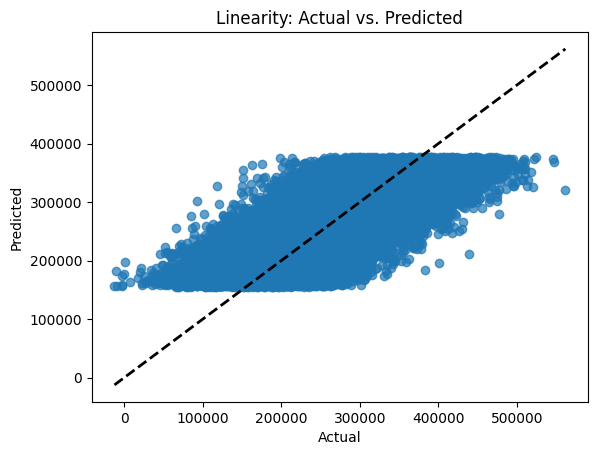

In [41]:
# Check linearity assumption by plotting actual vs. predicted values
plt.scatter(y, model.predict(), alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linearity: Actual vs. Predicted')
plt.show()

In [42]:
residuals = y - y_pred

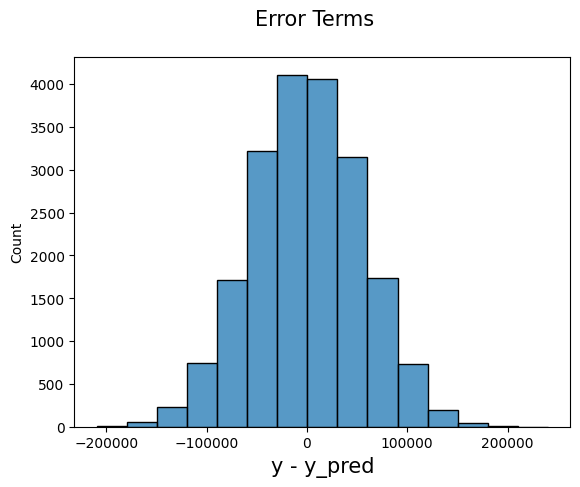

In [43]:
fig = plt.figure()
sns.histplot(residuals, bins = 15)
fig.suptitle('Error Terms', fontsize = 15)                  # Plot heading
plt.xlabel('y - y_pred', fontsize = 15)         # X-label
plt.show()

If the histogram exhibits a roughly bell-shaped curve with a single peak and comparable frequencies in each bin, it suggests that the residuals are approximately normally distributed.Here it is normally distributed

**Auto corelation**

The Durbin-Watson statistic is a test used to detect the presence of autocorrelation in the residuals of a regression model.

Here Durbin-Watson:	2.014 .
The test statistic ranges from 0 to 4, with values close to 2 indicating no significant autocorrelation.

**No Perfect Multicollinearity**

In [44]:
# Check for multicollinearity using variance inflation factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = X_with_const.copy()
vif_data = vif_data.drop(columns='const')  # Exclude the constant term
vif = pd.DataFrame()
vif["Variable"] = vif_data.columns
vif["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

print(vif)

            Variable       VIF
0          max_power  2.190602
1  transmission_type  1.726450
2        seller_self  1.715220


**Addressing VIF**

In [45]:
# fuel_electric is inf..that means duplicate may exist
X.columns[X.columns.duplicated()]
# if duplicate exist --remove it from X

Index([], dtype='object')

In [46]:
df[['engine','max_power']].corr()

,engine,max_power
engine,1.000000,0.003272
max_power,0.003272,1.000000


**Our intention should be lowering the value good R2 metric and VIF is less than 5**

**Linear Regression Model Development Steps:**

Develop a univariate linear regression model


to predict the selling price based on the input variable, max power.


Define three functions: linear hypothesis, gradient computation, and error computation.


Implement gradient descent to optimize the model parameters (Theta 0 and Theta 1).


Stopped gradient descent after a fixed number of iterations (e.g., 50).


Explain the importance of early stopping conditions for efficiency.